In [2]:
# data exploration
import pandas as pd

df = pd.read_csv("articles.csv")

# General info
print("DF dimensions:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nMemory size:")
mem_db = df.memory_usage(deep=True).sum() / 1024**2
print(f"{mem_db:.2f} MB")

print("\nFirst rows:")
print(df.head())

# Detailed info
print("\nTypes and nulls:")
df.info()


DF dimensions:
Rows: 105542
Columns: 25

Memory size:
106.25 MB

First rows:
   article_id  product_code          prod_name  product_type_no  \
0   108775015        108775          Strap top              253   
1   108775044        108775          Strap top              253   
2   108775051        108775      Strap top (1)              253   
3   110065001        110065  OP T-shirt (Idro)              306   
4   110065002        110065  OP T-shirt (Idro)              306   

  product_type_name  product_group_name  graphical_appearance_no  \
0          Vest top  Garment Upper body                  1010016   
1          Vest top  Garment Upper body                  1010016   
2          Vest top  Garment Upper body                  1010017   
3               Bra           Underwear                  1010016   
4               Bra           Underwear                  1010016   

  graphical_appearance_name  colour_group_code colour_group_name  ...  \
0                     Solid           

In [3]:
# data exploration
import pandas as pd

df = pd.read_csv("customers.csv")

# General info
print("DF dimensions:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nMemory size:")
mem_db = df.memory_usage(deep=True).sum() / 1024**2
print(f"{mem_db:.2f} MB")

print("\nFirst rows:")
print(df.head())

# Detailed info
print("\nTypes and nulls:")
df.info()


DF dimensions:
Rows: 1371980
Columns: 7

Memory size:
470.60 MB

First rows:
                                         customer_id   FN  Active  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...  NaN     NaN   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...  NaN     NaN   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...  NaN     NaN   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...  NaN     NaN   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...  1.0     1.0   

  club_member_status fashion_news_frequency   age  \
0             ACTIVE                   NONE  49.0   
1             ACTIVE                   NONE  25.0   
2             ACTIVE                   NONE  24.0   
3             ACTIVE                   NONE  54.0   
4             ACTIVE              Regularly  52.0   

                                         postal_code  
0  52043ee2162cf5aa7ee79974281641c6f11a68d276429a...  
1  2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...  
2  64f17e6a330a85798e499

In [6]:
# --- Descriptive Statistical Analysis ---
import pandas as pd

# Load dataset
df = pd.read_csv("articles.csv")  # ajusta la ruta si es necesario

# General Information
print("General Information:")
df.info()

# Summary Statistics (all types) 
print("\nDescriptive Statistics (all variables):")
desc = df.describe(include='all')
display(desc)

# Detailed per-column summary 
summary_list = []

for col in df.columns:
    dtype = df[col].dtype
    
    # Numeric columns
    if pd.api.types.is_numeric_dtype(df[col]):
        summary_list.append({
            "Variable": col,
            "Type": str(dtype),
            "Mean": df[col].mean(),
            "Median": df[col].median(),
            "Std Dev": df[col].std(),
            "Min": df[col].min(),
            "25%": df[col].quantile(0.25),
            "50%": df[col].quantile(0.50),
            "75%": df[col].quantile(0.75),
            "Max": df[col].max(),
            "Unique": df[col].nunique(),
            "Missing": df[col].isna().sum()
        })
        
    # Categorical columns
    elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
        summary_list.append({
            "Variable": col,
            "Type": str(dtype),
            "Unique categories": df[col].nunique(),
            "Most frequent (mode)": df[col].mode().iloc[0] if not df[col].mode().empty else None,
            "Frequency of mode": df[col].value_counts().iloc[0] if not df[col].value_counts().empty else None,
            "Missing": df[col].isna().sum()
        })
        
    # Datetime columns
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        summary_list.append({
            "Variable": col,
            "Type": "datetime",
            "Min date": df[col].min(),
            "Max date": df[col].max(),
            "Missing": df[col].isna().sum()
        })

# Convert to DataFrame for better visualization
summary_df = pd.DataFrame(summary_list)
display(summary_df)



General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
count,1.055420e+05,105542.000000,105542,105542.000000,105542,105542,1.055420e+05,105542,105542.000000,105542,...,105542,105542,105542,105542.000000,105542,105542.000000,105542,105542.000000,105542,105126
unique,NaN,NaN,45875,NaN,131,19,NaN,30,NaN,50,...,250,10,10,NaN,5,NaN,56,NaN,21,43404
top,NaN,NaN,Dragonfly dress,NaN,Trousers,Garment Upper body,NaN,Solid,NaN,Black,...,Jersey,A,Ladieswear,NaN,Ladieswear,NaN,Womens Everyday Collection,NaN,Jersey Fancy,T-shirt in printed cotton jersey.
freq,NaN,NaN,98,NaN,11169,42741,NaN,49747,NaN,22670,...,4604,26001,26001,NaN,39737,NaN,7295,NaN,21445,159
mean,6.984246e+08,698424.563378,NaN,234.861875,NaN,NaN,1.009515e+06,NaN,32.233822,NaN,...,NaN,NaN,NaN,3.171534,NaN,42.664219,NaN,1010.438290,NaN,NaN
std,1.284624e+08,128462.384432,NaN,75.049308,NaN,NaN,2.241359e+04,NaN,28.086154,NaN,...,NaN,NaN,NaN,4.353234,NaN,23.260105,NaN,6.731023,NaN,NaN
min,1.087750e+08,108775.000000,NaN,-1.000000,NaN,NaN,-1.000000e+00,NaN,-1.000000,NaN,...,NaN,NaN,NaN,1.000000,NaN,2.000000,NaN,1001.000000,NaN,NaN
25%,6.169925e+08,616992.500000,NaN,252.000000,NaN,NaN,1.010008e+06,NaN,9.000000,NaN,...,NaN,NaN,NaN,1.000000,NaN,20.000000,NaN,1005.000000,NaN,NaN
50%,7.022130e+08,702213.000000,NaN,259.000000,NaN,NaN,1.010016e+06,NaN,14.000000,NaN,...,NaN,NaN,NaN,2.000000,NaN,46.000000,NaN,1009.000000,NaN,NaN
75%,7.967030e+08,796703.000000,NaN,272.000000,NaN,NaN,1.010016e+06,NaN,52.000000,NaN,...,NaN,NaN,NaN,4.000000,NaN,61.000000,NaN,1017.000000,NaN,NaN


,Variable,Type,Mean,Median,Std Dev,Min,25%,50%,75%,Max,Unique,Missing,Unique categories,Most frequent (mode),Frequency of mode
0,article_id,int64,6.984246e+08,702213001.5,1.284624e+08,108775015.0,616992501.0,702213001.5,7.967030e+08,959461001.0,105542.0,0,NaN,NaN,NaN
1,product_code,int64,6.984246e+05,702213.0,1.284624e+05,108775.0,616992.5,702213.0,7.967030e+05,959461.0,47224.0,0,NaN,NaN,NaN
2,prod_name,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,45875.0,Dragonfly dress,98.0
3,product_type_no,int64,2.348619e+02,259.0,7.504931e+01,-1.0,252.0,259.0,2.720000e+02,762.0,132.0,0,NaN,NaN,NaN
4,product_type_name,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,131.0,Trousers,11169.0
5,product_group_name,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,19.0,Garment Upper body,42741.0
6,graphical_appearance_no,int64,1.009515e+06,1010016.0,2.241359e+04,-1.0,1010008.0,1010016.0,1.010016e+06,1010029.0,30.0,0,NaN,NaN,NaN
7,graphical_appearance_name,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,30.0,Solid,49747.0
8,colour_group_code,int64,3.223382e+01,14.0,2.808615e+01,-1.0,9.0,14.0,5.200000e+01,93.0,50.0,0,NaN,NaN,NaN
9,colour_group_name,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,50.0,Black,22670.0


In [7]:
# --- Descriptive Statistical Analysis ---
import pandas as pd

# Load dataset
df = pd.read_csv("customers.csv")  # ajusta la ruta si es necesario

# General Information
print("General Information:")
df.info()

# Summary Statistics (all types) 
print("\nDescriptive Statistics (all variables):")
desc = df.describe(include='all')
display(desc)

# Detailed per-column summary 
summary_list = []

for col in df.columns:
    dtype = df[col].dtype
    
    # Numeric columns
    if pd.api.types.is_numeric_dtype(df[col]):
        summary_list.append({
            "Variable": col,
            "Type": str(dtype),
            "Mean": df[col].mean(),
            "Median": df[col].median(),
            "Std Dev": df[col].std(),
            "Min": df[col].min(),
            "25%": df[col].quantile(0.25),
            "50%": df[col].quantile(0.50),
            "75%": df[col].quantile(0.75),
            "Max": df[col].max(),
            "Unique": df[col].nunique(),
            "Missing": df[col].isna().sum()
        })
        
    # Categorical columns
    elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_categorical_dtype(df[col]):
        summary_list.append({
            "Variable": col,
            "Type": str(dtype),
            "Unique categories": df[col].nunique(),
            "Most frequent (mode)": df[col].mode().iloc[0] if not df[col].mode().empty else None,
            "Frequency of mode": df[col].value_counts().iloc[0] if not df[col].value_counts().empty else None,
            "Missing": df[col].isna().sum()
        })
        
    # Datetime columns
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        summary_list.append({
            "Variable": col,
            "Type": "datetime",
            "Min date": df[col].min(),
            "Max date": df[col].max(),
            "Missing": df[col].isna().sum()
        })

# Convert to DataFrame for better visualization
summary_df = pd.DataFrame(summary_list)
display(summary_df)



General Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB

Descriptive Statistics (all variables):


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
count,1371980,476930.0,464404.0,1365918,1355969,1.356119e+06,1371980
unique,1371980,NaN,NaN,3,3,NaN,352899
top,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,NaN,2c29ae653a9282cce4151bd87643c907644e09541abc28...
freq,1,NaN,NaN,1272491,877711,NaN,120303
mean,NaN,1.0,1.0,NaN,NaN,3.638696e+01,NaN
std,NaN,0.0,0.0,NaN,NaN,1.431363e+01,NaN
min,NaN,1.0,1.0,NaN,NaN,1.600000e+01,NaN
25%,NaN,1.0,1.0,NaN,NaN,2.400000e+01,NaN
50%,NaN,1.0,1.0,NaN,NaN,3.200000e+01,NaN
75%,NaN,1.0,1.0,NaN,NaN,4.900000e+01,NaN


,Variable,Type,Unique categories,Most frequent (mode),Frequency of mode,Missing,Mean,Median,Std Dev,Min,25%,50%,75%,Max,Unique
0,customer_id,object,1371980.0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FN,float64,NaN,NaN,NaN,895050,1.000000,1.0,0.000000,1.0,1.0,1.0,1.0,1.0,1.0
2,Active,float64,NaN,NaN,NaN,907576,1.000000,1.0,0.000000,1.0,1.0,1.0,1.0,1.0,1.0
3,club_member_status,object,3.0,ACTIVE,1272491.0,6062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fashion_news_frequency,object,3.0,NONE,877711.0,16011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,age,float64,NaN,NaN,NaN,15861,36.386965,32.0,14.313628,16.0,24.0,32.0,49.0,99.0,84.0
6,postal_code,object,352899.0,2c29ae653a9282cce4151bd87643c907644e09541abc28...,120303.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Histogramas

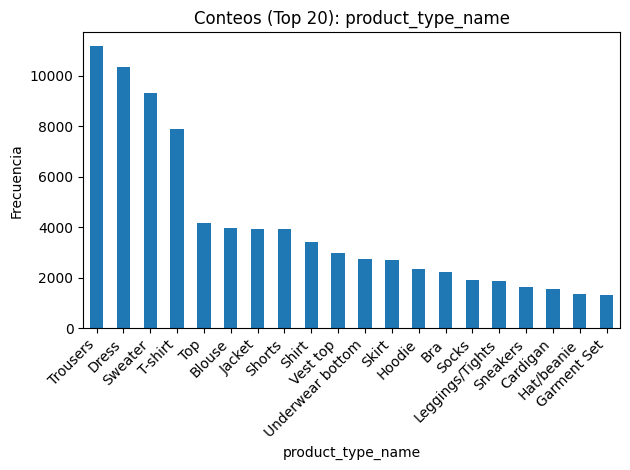

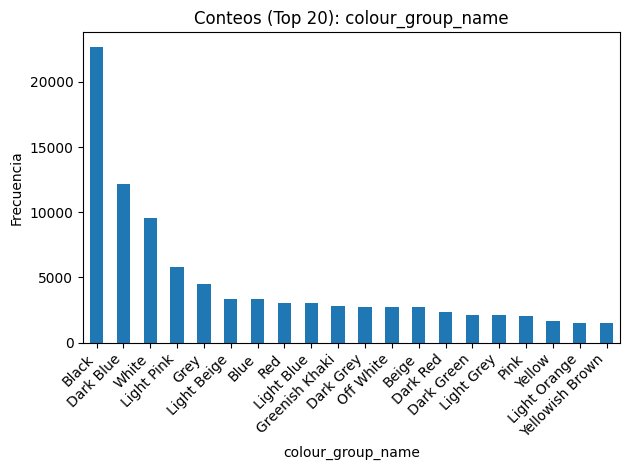

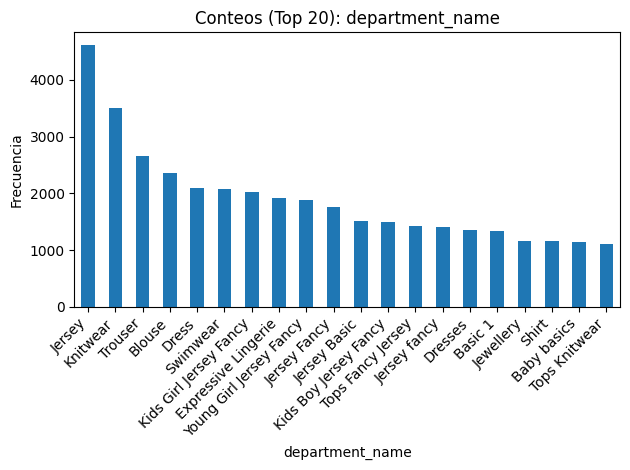

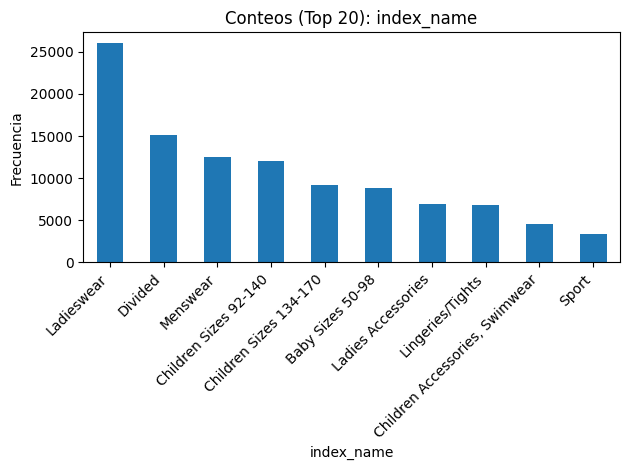

In [10]:
# Histograma (conteo) para columnas categóricas con matplotlib puro.
# Asume que ya tienes df cargado (por ejemplo desde /mnt/data/articles.csv)
import matplotlib.pyplot as plt
import pandas as pd
def plot_categorical_hist(df, col, top_n=20):
    counts = df[col].astype(str).value_counts().head(top_n)
    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Conteos (Top {top_n}): {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

df = pd.read_csv("articles.csv")
# Solicitud del usuario
plot_categorical_hist(df, "product_type_name", top_n=20)
plot_categorical_hist(df, "colour_group_name", top_n=20)
plot_categorical_hist(df, "department_name", top_n=20)
plot_categorical_hist(df, "index_name", top_n=20)

## Codigo para limpieza de datos

In [11]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher
import re

assert 'df' in globals(), "Debes tener un DataFrame llamado df."

N = len(df)
report = {}

# ------------------------------------------------------------
# 1) Valores Faltantes
# ------------------------------------------------------------
miss_tbl = (
    df.isna().mean().rename('pct_missing')
    .to_frame()
    .assign(n_missing=lambda x: (x['pct_missing']*N).round().astype(int))
    .sort_values('pct_missing', ascending=False)
)

def recommend_missing(p):
    if p == 0:
        return "Sin acción (0%)."
    if p <= 0.05:
        return "Imputar: numéricas→mediana, categóricas→moda."
    if p <= 0.30:
        return "Imputar con técnicas más robustas (kNN/árboles) o eliminar filas puntuales."
    return "Evaluar eliminar columna o imputación supervisada específica."

miss_tbl['recomendacion'] = miss_tbl['pct_missing'].apply(recommend_missing)
report['missing'] = miss_tbl

print("=== Valores Faltantes ===")
display(miss_tbl.style.format({'pct_missing':'{:.2%}'}))

# ------------------------------------------------------------
# 2) Valores Duplicados
# ------------------------------------------------------------
dup_rows = int(df.duplicated().sum())
dup_pct = dup_rows / N if N else 0

# Duplicados por clave candidata (columnas *_id o que contengan 'id')
pk_candidates = [c for c in df.columns if re.search(r'(?:^id$|id$|id)', c, re.I) or c.lower().endswith('id')]
dup_keys = {}
for c in pk_candidates:
    d = df[c]
    if d.isna().all():
        continue
    cnt = int(d.duplicated().sum())
    if cnt > 0:
        dup_keys[c] = cnt

report['duplicates'] = {'total_dup_rows': dup_rows, 'pct': dup_pct, 'by_keys': dup_keys}

print("\n=== Duplicados ===")
print(f"Filas duplicadas (completas): {dup_rows} ({dup_pct:.2%})")
if dup_keys:
    print("Duplicados por posibles claves (columnas tipo *_id):")
    for k, v in dup_keys.items():
        print(f"  - {k}: {v} duplicados")
else:
    print("Sin duplicados relevantes en claves candidatas (si existen).")

# Decisión sugerida:
if dup_rows > 0:
    print("Decisión sugerida: eliminar filas duplicadas exactas con df = df.drop_duplicates().")
else:
    print("Decisión sugerida: no se requieren acciones sobre duplicados.")

# ------------------------------------------------------------
# 3) Inconsistencias
#    3.1 Outliers numéricos (Tukey/IQR)
# ------------------------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = []
outlier_indices_example = {}

for col in num_cols:
    s = df[col].dropna()
    if s.empty: 
        continue
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    mask = (df[col] < low) | (df[col] > high)
    n_out = int(mask.sum())
    pct_out = n_out / N if N else 0
    outlier_summary.append((col, n_out, pct_out, low, high))
    if n_out > 0:
        outlier_indices_example[col] = df.loc[mask, col].head(5)

outlier_tbl = pd.DataFrame(outlier_summary, columns=['columna','n_outliers','pct_outliers','low_fence','high_fence'])
outlier_tbl = outlier_tbl.sort_values('pct_outliers', ascending=False)
report['outliers'] = outlier_tbl

print("\n=== Outliers (IQR/Tukey) ===")
if len(outlier_tbl):
    display(outlier_tbl.style.format({'pct_outliers':'{:.2%}','low_fence':'{:.4g}','high_fence':'{:.4g}'}))
else:
    print("No se detectaron columnas numéricas para evaluar.")
if outlier_indices_example:
    print("Ejemplos de outliers (primeras 5 filas por columna):")
    for c, ex in outlier_indices_example.items():
        print(f"\n> {c}")
        display(ex)

# Regla simple sobre negativos en variables que deberían ser no negativas
neg_summary = []
for col in num_cols:
    neg = int((df[col] < 0).sum())
    if neg > 0:
        neg_summary.append((col, neg))
if neg_summary:
    print("\nPosibles violaciones (valores negativos donde no deberían):")
    for c, n in neg_summary:
        print(f"  - {c}: {n} valores negativos")
report['negatives'] = neg_summary

# ------------------------------------------------------------
#    3.2 Inconsistencias de formato en categóricas
#         - espacios, mayúsculas/minúsculas
#         - variantes muy similares (heurística simple)
# ------------------------------------------------------------
cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()

def normalize_token(x: str) -> str:
    x = x.strip()
    x = re.sub(r'\s+', ' ', x)          # colapsar espacios
    x = x.casefold()                     # case-insensitive robusto
    x = re.sub(r'[^a-z0-9 ]+', '', x)   # quitar signos y acentos basicos
    return x

format_issues = []
fuzzy_suspects = {}

for col in cat_cols:
    s = df[col].astype(str)
    # espacios
    leading_trailing = int((s != s.str.strip()).sum())
    multi_spaces = int(s.str.contains(r'\s{2,}', regex=True).sum())
    case_variants = s.nunique() - s.str.casefold().nunique()
    norm = s.apply(normalize_token)
    collisions = int(norm.nunique() < s.nunique())  # normalización reduce cardinalidad
    format_issues.append([col, leading_trailing, multi_spaces, case_variants, int(collisions)])

 
    uniq = s.unique()
    if len(uniq) <= 50:
        pairs = []
        for i in range(len(uniq)):
            for j in range(i+1, len(uniq)):
                a, b = str(uniq[i]), str(uniq[j])
                sim = SequenceMatcher(None, normalize_token(a), normalize_token(b)).ratio()
                if 0.85 <= sim < 1.0 and normalize_token(a) != normalize_token(b):
                    pairs.append((a, b, round(sim, 2)))
        if pairs:
            fuzzy_suspects[col] = pairs[:20]  # recorta
format_tbl = pd.DataFrame(format_issues, columns=['columna','con_espacios_borde','con_multi_espacios','variantes_mayus/minus','colisiones_por_normalizacion'])
report['categorical_format'] = format_tbl

print("\n=== Inconsistencias de Formato (categóricas) ===")
if len(format_tbl):
    display(format_tbl.sort_values(['con_espacios_borde','con_multi_espacios','variantes_mayus/minus'], ascending=False))
else:
    print("No se detectaron columnas categóricas.")

if fuzzy_suspects:
    print("\nPosibles categorías casi duplicadas (similitud ≥ 0.85):")
    for c, pairs in fuzzy_suspects.items():
        print(f"> {c}:")
        for a,b,sim in pairs:
            print(f"  '{a}'  ~  '{b}'  (sim={sim})")

# Recomendación de limpieza para categóricas
print("\nSugerencia base para categóricas:")
print("- Aplicar .str.strip(), colapsar múltiples espacios y unificar mayúsc/minúsculas.")
print("- Revisar pares con alta similitud para unificar etiquetas (ej. 'T-shirt' vs 'T shirt').")


high_missing_cols = miss_tbl.query('pct_missing >= 0.30').index.tolist()
some_missing_cols = miss_tbl.query('pct_missing > 0 and pct_missing < 0.30').index.tolist()
cols_with_outliers = outlier_tbl.query('pct_outliers >= 0.01')['columna'].tolist()

conclusion = []
conclusion.append(f"Se analizaron {N} filas y {df.shape[1]} columnas.")
conclusion.append(f"Duplicados exactos: {dup_rows} ({dup_pct:.2%}).")
if high_missing_cols:
    conclusion.append(f"{len(high_missing_cols)} columna(s) con >30% faltantes: {', '.join(high_missing_cols[:8])}...")
if some_missing_cols:
    conclusion.append(f"{len(some_missing_cols)} columna(s) con faltantes moderados (0–30%).")
if cols_with_outliers:
    conclusion.append(f"Outliers relevantes (≥1% de filas) en: {', '.join(cols_with_outliers[:10])}.")
if neg_summary:
    bad = ", ".join([f"{c}({n})" for c,n in neg_summary][:8])
    conclusion.append(f"Se detectaron valores negativos inusuales en: {bad}.")

conclusion.append("Formateo categórico: se observaron posibles inconsistencias (espacios/capitalización) y etiquetas casi duplicadas que conviene normalizar.")

impacto = (
    "Impacto: se recomienda *eliminar duplicados, **imputar faltantes* (mediana/moda o técnicas avanzadas según el caso), "
    "*revisar y tratar outliers* si afectan al modelo, y *normalizar categóricas* para evitar categorías espurias. "
    "Con estas correcciones, el conjunto será apto para análisis descriptivo y modelado inicial."
)

print("\n=== Conclusiones de Calidad (resumen) ===")
print(" ".join(conclusion))
print(impacto)


cleaning_plan = {
    "drop_duplicates": dup_rows > 0,
    "impute": {
        "numeric": "mediana (faltantes ≤5%), técnicas avanzadas 5–30%",
        "categorical": "moda (faltantes ≤5%), revisión 5–30%"
    },
    "treat_outliers": "winsorizar/recortar o modelar robusto según variable",
    "normalize_categoricals": ["strip", "casefold", "espacios múltiples -> uno", "revisar pares similares"]
}
report['plan_sugerido'] = cleaning_plan

=== Valores Faltantes ===


,pct_missing,n_missing,recomendacion
detail_desc,0.39%,416,"Imputar: numéricas→mediana, categóricas→moda."
product_code,0.00%,0,Sin acción (0%).
prod_name,0.00%,0,Sin acción (0%).
product_type_no,0.00%,0,Sin acción (0%).
product_type_name,0.00%,0,Sin acción (0%).
product_group_name,0.00%,0,Sin acción (0%).
graphical_appearance_no,0.00%,0,Sin acción (0%).
graphical_appearance_name,0.00%,0,Sin acción (0%).
article_id,0.00%,0,Sin acción (0%).
colour_group_code,0.00%,0,Sin acción (0%).



=== Duplicados ===
Filas duplicadas (completas): 0 (0.00%)
Duplicados por posibles claves (columnas tipo *_id):
  - perceived_colour_value_id: 105534 duplicados
  - perceived_colour_master_id: 105522 duplicados
Decisión sugerida: no se requieren acciones sobre duplicados.

=== Outliers (IQR/Tukey) ===


,columna,n_outliers,pct_outliers,low_fence,high_fence
2,product_type_no,24069,22.81%,222,302
8,index_group_no,3392,3.21%,-3.5,8.5
0,article_id,1393,1.32%,3.474e+08,1.066e+09
1,product_code,1393,1.32%,3.474e+05,1.066e+06
3,graphical_appearance_no,60,0.06%,1.01e+06,1.01e+06
5,perceived_colour_value_id,0,0.00%,-1,7
4,colour_group_code,0,0.00%,-55.5,116.5
6,perceived_colour_master_id,0,0.00%,-6.5,21.5
7,department_no,0,0.00%,-6894,1.596e+04
9,section_no,0,0.00%,-41.5,122.5


Ejemplos de outliers (primeras 5 filas por columna):

> article_id


...


> index_group_no


40    26
41    26
42    26
43    26
44    26
Name: index_group_no, dtype: int64


Posibles violaciones (valores negativos donde no deberían):
  - product_type_no: 121 valores negativos
  - graphical_appearance_no: 52 valores negativos
  - colour_group_code: 28 valores negativos
  - perceived_colour_value_id: 28 valores negativos
  - perceived_colour_master_id: 685 valores negativos

=== Inconsistencias de Formato (categóricas) ===


,columna,con_espacios_borde,con_multi_espacios,variantes_mayus/minus,colisiones_por_normalizacion
0,prod_name,0,517,1788,1
13,detail_desc,0,44,9,1
7,department_name,0,0,2,1
1,product_type_name,0,0,1,1
2,product_group_name,0,0,0,0
3,graphical_appearance_name,0,0,0,0
4,colour_group_name,0,0,0,0
5,perceived_colour_value_name,0,0,0,0
6,perceived_colour_master_name,0,0,0,0
8,index_code,0,0,0,0



Posibles categorías casi duplicadas (similitud ≥ 0.85):
> colour_group_name:
  'Light Grey'  ~  'Light Green'  (sim=0.86)
> index_name:
  'Children Sizes 92-140'  ~  'Children Sizes 134-170'  (sim=0.88)

Sugerencia base para categóricas:
- Aplicar .str.strip(), colapsar múltiples espacios y unificar mayúsc/minúsculas.
- Revisar pares con alta similitud para unificar etiquetas (ej. 'T-shirt' vs 'T shirt').

=== Conclusiones de Calidad (resumen) ===
Se analizaron 105542 filas y 25 columnas. Duplicados exactos: 0 (0.00%). 1 columna(s) con faltantes moderados (0–30%). Outliers relevantes (≥1% de filas) en: product_type_no, index_group_no, article_id, product_code. Se detectaron valores negativos inusuales en: product_type_no(121), graphical_appearance_no(52), colour_group_code(28), perceived_colour_value_id(28), perceived_colour_master_id(685). Formateo categórico: se observaron posibles inconsistencias (espacios/capitalización) y etiquetas casi duplicadas que conviene normalizar.
Impacto